# Jacobian Lens — Week 1

**csinatra**

A batch Jacobian-lens read-out over the prompt sets in the repo's own
`data/experiments/`, aggregated into a per-layer summary.

## What this covers

| Assignment step | Where |
|---|---|
| 1. Set up the lens, run `walkthrough.ipynb`, render a slice-vis page | §1 (slice page rendered separately; see note) |
| 2. `lens.apply()` over **every valid source position**, one column per position × one row per layer | §3 |
| 3. Per prompt × layer × position, extract **top-1 token and its rank**, matching the slice-vis display | §3–§4 |
| 4. Per-layer summary aggregated over all positions and all prompts | §5 |
| Additional visualisations / observations | §6–§7 |

## Model choice

The brief specifies a pre-fitted lens on **Qwen3.6-27B**. This run uses
**Qwen3.5-4B**, under the brief's compute note ("feel free to use a smaller
Qwen model with an available pre-fitted lens") — the hardware here is a 32 GB
M4 MacBook Air, where the 27B model's weights alone would not leave room for
the read-out. Both lenses come from the same `neuronpedia/jacobian-lens`
repo at revision `qwen-n1000`, so the method is identical; only the scale
differs. Layer indices below therefore refer to a **32-layer** model.

## Method summary

At each `(prompt, position, layer)` cell the lens produces a distribution over
the full vocabulary. Two distinct things are recorded, matching what the
slice-vis page shows:

- **the displayed token** — the top-1 *after* the repo's word-like display
  mask (`mask_display=True` in `compute_slice`). Unmasked, the arg-max at a
  given position is very often punctuation or whitespace.
- **its rank** — that token's rank in the **unmasked, full-vocab** ordering.
  `rank == 0` means the word-like token was already the outright arg-max.

The headline result is that these two are not the same question, and reading
`rank == 0` as a quality score is a mistake — see §7.

## 0. Setup

`jlens` itself is imported, not reimplemented: prompt assembly goes through the
repo's own `jlens.examples.resolve_prompt` (so chat prompts use the tokenizer's
chat template), the display mask is the repo's own
`jlens.vis._meaningful_token_mask`, and the read-out is the repo's own
`lens.apply()`. Everything inlined below is this submission's own code.

In [1]:
# If jlens is not already installed:
# %pip install -q "jlens @ git+https://github.com/anthropics/jacobian-lens"
# %pip install -q pandas matplotlib pyarrow tabulate python-dotenv

import gc, json, math, os, random, textwrap, time, urllib.request
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import transformers

import jlens
from jlens.examples import Example, resolve_prompt
from jlens.vis import _meaningful_token_mask

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
jlens.configure_logging()

# Keep the saved outputs readable: no download progress bars, no HF chatter.
from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()
transformers.logging.set_verbosity_error()

# HF_TOKEN from .env if present (gated repos / rate limits).
try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd() / ".env", override=True)
except ImportError:
    pass

from importlib.metadata import version as _pkg_version
print("jlens       ", _pkg_version("jlens"))
print("torch     ", torch.__version__, "| mps:", torch.backends.mps.is_available())
print("transformers", transformers.__version__)

jlens        0.1.0
torch      2.14.0 | mps: True
transformers 5.16.1


### Configuration

`MAX_SEQ_LEN` and `LAYER_CHUNK` are the memory knobs — see §3 for why they
matter. `PER_EXPERIMENT` is the compute knob.

In [2]:
MODEL_NAME    = "Qwen/Qwen3.5-4B"
LENS_REPO     = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE     = "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt"

PER_EXPERIMENT = 32      # prompts drawn per experiment file -> 292 total
MAX_SEQ_LEN    = 256     # prompt truncation (memory knob)
LAYER_CHUNK    = 4       # layers per apply() call (memory knob)
LAYER_STRIDE   = 1       # every fitted layer
SEED           = 0

CACHE_DIR = Path("_sweep_cache")   # per-prompt grids; run is resumable
CACHE_DIR.mkdir(exist_ok=True)

## 1. Load the model and the pre-fitted lens

`jlens.from_hf` wraps a HuggingFace model into the `LensModel` interface;
`JacobianLens.from_pretrained` pulls the fitted `J_l` matrices from the Hub.

In [3]:
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).to(device)
hf_model.eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)

lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
print("device:", device)
print(model)
print(lens)

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

device: mps
HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)
JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))


> **Slice-vis page (assignment step 1).** The `walkthrough.ipynb` notebook was
> run top-to-bottom against this same model and lens, and both the inline
> (`mode="embed"`) and served (`mode="fetch"`) slice pages rendered correctly.
> That page is a single-prompt artefact; this notebook is the batch
> generalisation of it, so the page itself is not re-embedded here.

## 2. Prompts from `data/experiments/`

Each `{slug}.json` has its own schema (see the directory's `README.md`), so
there is one adapter per file. Every adapter yields `jlens.examples.Example`
objects, which means chat-mode prompts are assembled by the repo's own
`resolve_prompt` — i.e. the tokenizer's chat template, exactly as the bundled
examples are.

**Scope note.** Several experiments are *interventional* (representation swaps,
lens steering, embedding interpolation). A read-out sweep only needs the
forward-pass prompt, so the adapters emit the **baseline / control /
strength-0** form of each trial and never apply an intervention.

In [4]:
# The experiment JSONs live in the jacobian-lens repo. Use a local checkout if
# one is present, otherwise fetch them (Apache-2.0, same as the code).
EXPERIMENT_FILES = [
    "capacity", "directed-modulation", "dual-task", "flexible-generalization",
    "ignition", "probe-swap", "selectivity-language", "selectivity-linecount",
    "top-down-summoning", "verbal-introspection", "verbal-report",
]
RAW = "https://raw.githubusercontent.com/anthropics/jacobian-lens/main/data/experiments"

def experiments_dir() -> Path:
    for candidate in (Path("data/experiments"), Path("../data/experiments"),
                      Path("../../jacobian-lens/data/experiments")):
        if candidate.is_dir():
            return candidate
    local = Path("_experiments"); local.mkdir(exist_ok=True)
    for slug in EXPERIMENT_FILES:
        path = local / f"{slug}.json"
        if not path.exists():
            with urllib.request.urlopen(f"{RAW}/{slug}.json", timeout=60) as response:
                path.write_bytes(response.read())
    return local

DATA_DIR = experiments_dir()
source = "downloaded" if DATA_DIR.name == "_experiments" else "local jacobian-lens checkout"
print(f"experiment prompts from: {DATA_DIR}  ({source})")

experiment prompts from: ../../jacobian-lens/data/experiments  (local jacobian-lens checkout)


In [5]:
@dataclass(frozen=True)
class PromptRec:
    """One prompt drawn from an experiment file. `uid` is the grid filename."""
    uid: str
    experiment: str
    variant: str
    example: Example

    def text(self, tokenizer) -> str:
        return resolve_prompt(self.example, tokenizer)   # jlens' own assembly


_ADAPTERS = {}

def _adapter(slug):
    def register(fn):
        _ADAPTERS[slug] = fn
        return fn
    return register

def _slugify(text: str) -> str:
    return "".join(c if (c.isalnum() or c in "-_") else "-" for c in text).strip("-")[:60]

def _ex(slug, section, description, **kwargs) -> Example:
    return Example(slug=slug, section=section, description=description, **kwargs)

In [6]:
@_adapter("probe-swap")
def _probe_swap(data, rng):
    """90 two-hop factual prompts, raw text. Baseline form (no swap)."""
    for item in data["items"]:
        yield item["name"], _ex("probe-swap", f"Multi-hop: {item['category']}",
                                f"{item['intermediate']} -> {item['answer']}",
                                prompt=item["prompt"])

@_adapter("flexible-generalization")
def _flexible(data, rng):
    """One trial per (category, function template, argument)."""
    for cat in data["categories"]:
        for func in cat["funcs"]:
            for arg in cat["args"]:
                yield (f"{cat['name']}-{func['name']}-{_slugify(arg)}",
                       _ex("flexible-generalization",
                           f"Flexible generalization: {cat['name']}/{func['name']}",
                           f"answer = {func['answers'].get(arg, '?')}",
                           prompt=func["template"].format(arg=arg)))

@_adapter("ignition")
def _ignition(data, rng):
    """Carrier sentences with {W} filled by a concept word (alpha=0/1 endpoints)."""
    words = list(data["countries_12"]) + list(data["alt_words"])
    templates = list(data["ctx_templates"]) + list(data["noun_ctx_templates"])
    for i, template in enumerate(templates):
        word = words[i % len(words)]
        yield (f"ctx{i:03d}-{_slugify(word)}",
               _ex("ignition", "Ignition carrier", f"carrier sentence, W = {word}",
                   prompt=template.replace("{W}", word)))

@_adapter("directed-modulation")
def _directed_modulation(data, rng):
    """One trial per (phrasing, carrier, target); topic and arithmetic families."""
    kinds = data["group_kind"]
    targets = [("topic", t["name"]) for t in data["topic_categories"]]
    targets += [("math", m["expr"]) for m in data["math_problems"]]
    carriers = data["carrier_sentences"]
    for p, phrasing in enumerate(data["phrasings"]):
        for t, (family, x) in enumerate(targets):
            carrier = carriers[(p + t) % len(carriers)]
            yield (f"{phrasing['name']}-{family}-{_slugify(x)}",
                   _ex("directed-modulation",
                       f"Directed modulation: {kinds[phrasing['group']]}",
                       f"{phrasing['name']} / target {x!r}",
                       user=f'Write "{carrier}" {phrasing["text"].format(x=x)} '
                            "Don't write anything else.",
                       assistant_prefill=carrier))

@_adapter("dual-task")
def _dual_task(data, rng):
    """The four concept/math conditions over each concept pair entry."""
    carrier = data["carrier_sentence"]
    def instruction(concept, math_expr, order):
        parts = []
        for which in order:
            if which == "concept" and concept:
                parts.append(f"concentrate on {concept}")
            elif which == "math" and math_expr:
                parts.append(f"try to evaluate {math_expr}")
        joined = " and ".join(parts)
        joined = joined[:1].upper() + joined[1:]
        return (f'Write "{carrier}" {joined} while you write the sentence. '
                "Don't write anything else.")
    for pair in data["pairs"]:
        expr = f"{pair['base']}^{pair['exp']} - {pair['sub']}"
        for name, (concept, m, order) in {
            "concept":       (pair["concept"], None, ["concept"]),
            "math":          (None, expr, ["math"]),
            "concept_first": (pair["concept"], expr, ["concept", "math"]),
            "math_first":    (pair["concept"], expr, ["math", "concept"]),
        }.items():
            yield (f"{pair['key']}-{name}",
                   _ex("dual-task", f"Dual task: {name}",
                       f"concept={pair['concept']} math={expr}",
                       user=instruction(concept, m, order), assistant_prefill=carrier))

In [7]:
@_adapter("selectivity-language")
def _selectivity_language(data, rng):
    """Each passage under both the explicit and the automatic question."""
    for passage in data["passages"]:
        for cond in ("explicit_q", "automatic_q"):
            yield (f"{passage['key']}-{cond}",
                   _ex("selectivity-language", f"Language selectivity: {cond}",
                       f"{passage['category']} passage {passage['key']}",
                       user=data["task"][cond].format(text=passage["text"])))

@_adapter("selectivity-linecount")
def _selectivity_linecount(data, rng):
    """Each passage under none/direct/letter conditions, plus `continue`."""
    for passage in data["passages"]:
        wrapped = textwrap.fill(passage["text"], width=passage["width"])
        for name, cond in data["conditions"].items():
            question = cond["question"]
            yield (f"{passage['tag']}-{name}",
                   _ex("selectivity-linecount", f"Line-count selectivity: {name}",
                       f"passage {passage['tag']} wrapped at {passage['width']}",
                       user=f"{question}\n\n{wrapped}" if question else wrapped,
                       assistant_prefill=cond["prefill"]))
        yield (f"{passage['tag']}-continue",
               _ex("selectivity-linecount", "Line-count selectivity: continue",
                   f"passage {passage['tag']} wrapped at {passage['width']}",
                   user=f"{data['explicit_q']}\n\n{wrapped}"))

@_adapter("top-down-summoning")
def _top_down(data, rng):
    """Each stimulus under the shared Q1 and its own Q2."""
    for item in data["items"]:
        for name, question in (("q1", data["q1"]), ("q2", item["q2"])):
            yield (f"{item['key']}-{name}",
                   _ex("top-down-summoning", f"Top-down summoning: {name}",
                       f"expected={item['expected']} foil={item['foil']}",
                       user=f"{item['stimulus']}\n\n{question}"))

@_adapter("verbal-introspection")
def _verbal_introspection(data, rng):
    """The introspection prompt at strength 0 (control), per concept x prefill."""
    turns = data["intro_prompt"]
    system = next((t["content"] for t in turns if t["role"] == "system"), None)
    user = "\n\n".join(t["content"] for t in turns if t["role"] == "user")
    for concept in data["concepts"]:
        for name, prefill in data["prefills"].items():
            yield (f"{_slugify(concept['name'])}-{name}",
                   _ex("verbal-introspection", f"Verbal introspection: {name} prefill",
                       f"control (strength 0), concept {concept['surface']!r}",
                       system=system, user=user, assistant_prefill=prefill))

@_adapter("verbal-report")
def _verbal_report(data, rng):
    """`Think of a {category}` with a prefill ending in the scored `:`."""
    for category in data["candidates"]:
        yield (category,
               _ex("verbal-report", "Verbal report", f"category {category}",
                   user=f"Think of a {category}. Answer in one word.",
                   assistant_prefill=f"The {category} I am thinking of is:"))

@_adapter("capacity")
def _capacity(data, rng):
    """80-word lists: four 20-word blocks, one per family, order shuffled.

    The published construction filters each pool to single-token words; this
    samples from the head of each pool instead (short, overwhelmingly
    single-token). The lens grid does not depend on that filter.
    """
    pools = {p["name"]: p["pool"] for p in data["candidate_pools"]}
    for trial in range(24):
        order = list(data["block_families"])
        rng.shuffle(order)
        words = []
        for family in order:
            words.extend(rng.sample(pools[family][:120], 20))
        yield (f"trial{trial:03d}",
               _ex("capacity", "Capacity: 80-word list",
                   f"block order {', '.join(order)}", prompt=", ".join(words)))

print(f"{len(_ADAPTERS)} adapters registered")

11 adapters registered


### Loading and selecting

Two details that matter for correctness:

- **Variant names are de-duplicated.** The uid is the grid's filename, so a
  collision would make two prompts silently overwrite each other's results.
  `_slugify` folds `*`, `+` and `-` to the same character, so
  `directed-modulation`'s `4 * 2` and `4 + 2` targets would otherwise collide
  (24 of them do).
- **Selection is prefix-stable.** Each experiment's list is shuffled once per
  `(seed, slug)` and the first N taken, so the set for a given
  `PER_EXPERIMENT` is always a subset of the set for any larger one. Raising it
  and re-running against the same cache therefore computes exactly the
  increment. (`random.sample` is *not* prefix-stable across sample sizes,
  which is why this shuffles instead.)

In [8]:
def load_experiment(slug, data_dir=None, seed=SEED):
    """Every prompt an experiment file yields, with de-duplicated variant names."""
    data_dir = Path(data_dir or DATA_DIR)
    data = json.loads((data_dir / f"{slug}.json").read_text(encoding="utf-8"))
    rng = random.Random(f"{seed}:{slug}")
    seen, records = Counter(), []
    for variant, example in _ADAPTERS[slug](data, rng):
        seen[variant] += 1
        if seen[variant] > 1:
            variant = f"{variant}#{seen[variant]}"
        records.append(PromptRec(f"{slug}/{variant}", slug, variant, example))
    return records


def select_prompts(per_experiment=PER_EXPERIMENT, experiments=None, seed=SEED):
    """Balanced, prefix-stable selection, interleaved across experiments so that
    stopping early still leaves a balanced set."""
    per_slug = []
    for slug in (experiments or sorted(_ADAPTERS)):
        candidates = load_experiment(slug, seed=seed)
        rng = random.Random(f"{seed}:select:{slug}")
        rng.shuffle(candidates)
        per_slug.append(candidates[:per_experiment])
    out = []
    for i in range(max((len(c) for c in per_slug), default=0)):
        out.extend(c[i] for c in per_slug if i < len(c))
    return out


inventory = {slug: len(load_experiment(slug)) for slug in sorted(_ADAPTERS)}
prompts = select_prompts()
chosen = Counter(p.experiment for p in prompts)
print(f"{sum(inventory.values())} prompts available; {len(prompts)} selected\n")
print(f"{'experiment':<26}{'available':>10}{'selected':>10}")
for slug, n in inventory.items():
    print(f"{slug:<26}{n:>10}{chosen[slug]:>10}")

1716 prompts available; 292 selected

experiment                 available  selected
capacity                          24        24
directed-modulation             1104        32
dual-task                         84        32
flexible-generalization           64        32
ignition                          60        32
probe-swap                        90        32
selectivity-language              16        16
selectivity-linecount             44        32
top-down-summoning                14        14
verbal-introspection             202        32
verbal-report                     14        14


In [9]:
# Sanity: uids must be unique, both as ids and as filenames.
for slug in _ADAPTERS:
    recs = load_experiment(slug)
    assert len({r.uid for r in recs}) == len(recs), slug
    assert len({r.uid.replace("/", "__") for r in recs}) == len(recs), slug

# Prefix-stability: every smaller selection is a subset of every larger one.
prev = None
for pe in (8, 16, 32, 64):
    s = {r.uid for r in select_prompts(per_experiment=pe)}
    assert prev is None or prev <= s, pe
    prev = s
print("uid uniqueness and prefix-stability: OK")

example_rec = next(r for r in prompts if r.experiment == "dual-task")
print(f"\nexample chat prompt ({example_rec.uid}):\n{example_rec.text(tokenizer)!r}")

uid uniqueness and prefix-stability: OK

example chat prompt (dual-task/farm-math):
'<|im_start|>user\nWrite "The old painting hung crookedly on the wall." Try to evaluate 2^3 - 5 while you write the sentence. Don\'t write anything else.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nThe old painting hung crookedly on the wall.'


## 3. The grid: `lens.apply()` over every source position

`lens.apply(model, prompt, positions=None)` returns one
`[n_positions, vocab_size]` logit tensor **per requested layer** — that is the
full slice-vis grid, one column per position and one row per layer.

**Why this is chunked over layers.** For Qwen3.5-4B the logit width is 248,320,
so one layer at 256 positions is `256 x 248320 x 4 bytes = 254 MB`. Asking for
all 31 fitted layers in a single `apply()` call would allocate ~7.9 GB before
anything else — enough to push a 32 GB machine into swap alongside the model.
So the sweep calls `apply()` in chunks of `LAYER_CHUNK` layers and **reduces
each chunk to scalars before requesting the next**. Peak stays at
`LAYER_CHUNK` blocks regardless of how many layers the lens has; the cost is
one extra forward pass per chunk, which is small next to the unembed. Measured
peak RSS at the defaults: **~3.7 GB**.

**What is extracted per cell,** matching the slice-vis display:

- `top1_id` — arg-max *after* the repo's word-like display mask.
- `top1_rank` — that token's rank in the **unmasked, full-vocab** ordering,
  computed as `(logits > top_logit).sum()`. This is the exact 0-based rank
  (equivalent to `jlens.vis._ranks_of`'s argsort, without materialising a
  vocab-wide sort buffer).
- `top1_prob`, `entropy_bits` — sharpness of the read-out.
- `raw_top1_id` — the *unmasked* arg-max, kept so the masking effect is
  measurable rather than assumed (used in §7).

The final row is the model's own output distribution — the `J = I` row the
slice page draws at the bottom.

In [10]:
_LN2 = math.log(2.0)
_MASK_IDX_CACHE = {}

def display_mask_idx(tokenizer, vocab_size):
    """Indices of word-like tokens, from the repo's own display mask.
    Cached: building it decodes the entire vocabulary once."""
    key = (id(tokenizer), vocab_size)
    if key not in _MASK_IDX_CACHE:
        mask = _meaningful_token_mask(tokenizer, vocab_size, torch.device("cpu"))
        _MASK_IDX_CACHE[key] = mask.nonzero(as_tuple=True)[0].contiguous()
    return _MASK_IDX_CACHE[key]


def reduce_block(logits, mask_idx, pos_chunk=64):
    """Reduce [n_positions, vocab_size] logits to per-position summaries.

    Chunked over positions so the transient buffers (a vocab-wide log-softmax,
    a masked column gather) stay bounded by `pos_chunk` rows.
    """
    n = logits.shape[0]
    out = {k: np.empty(n, dtype=t) for k, t in
           [("top1_id", np.int32), ("top1_rank", np.int32), ("top1_prob", np.float32),
            ("raw_top1_id", np.int32), ("entropy_bits", np.float32)]}
    for start in range(0, n, pos_chunk):
        sl = slice(start, min(start + pos_chunk, n))
        block = logits[sl]
        raw_top = block.argmax(dim=-1)
        if mask_idx is None:
            top = raw_top
        else:
            masked = block.index_select(1, mask_idx)
            top = mask_idx[masked.argmax(dim=-1)]
            del masked
        top_logit = block.gather(1, top[:, None])
        # Full-vocab rank: how many vocabulary entries outscore the displayed
        # token. 0 == the displayed token is the model's actual arg-max.
        rank = (block > top_logit).sum(dim=-1)
        log_probs = block.log_softmax(dim=-1)
        probs = log_probs.exp()
        entropy = -(probs * log_probs).sum(dim=-1) / _LN2
        prob = probs.gather(1, top[:, None]).squeeze(1)
        del log_probs, probs
        out["top1_id"][sl] = top.numpy()
        out["top1_rank"][sl] = rank.numpy()
        out["top1_prob"][sl] = prob.numpy()
        out["raw_top1_id"][sl] = raw_top.numpy()
        out["entropy_bits"][sl] = entropy.numpy()
    return out


def empty_cache():
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

In [11]:
@torch.no_grad()
def top1_grid(model, lens, rec, layer_stride=LAYER_STRIDE, layer_chunk=LAYER_CHUNK,
              max_seq_len=MAX_SEQ_LEN, mask_display=True):
    """Full position x layer grid for one prompt, via the repo's `lens.apply`."""
    prompt = rec.text(model.tokenizer)
    fitted = lens.source_layers[::layer_stride]
    if lens.source_layers[-1] not in fitted:
        fitted.append(lens.source_layers[-1])
    final_layer = model.n_layers - 1

    columns = {k: [] for k in
               ("top1_id", "top1_rank", "top1_prob", "raw_top1_id", "entropy_bits")}
    mask_idx = model_cols = input_ids_np = None
    vocab_size = 0

    for start in range(0, len(fitted), layer_chunk):
        chunk = fitted[start:start + layer_chunk]
        # positions=None -> EVERY valid source position in the prompt.
        lens_logits, model_logits, input_ids = lens.apply(
            model, prompt, layers=chunk, positions=None, max_seq_len=max_seq_len)
        if input_ids_np is None:
            input_ids_np = input_ids[0].cpu().numpy().astype(np.int32)
        vocab_size = int(model_logits.shape[-1])
        if mask_display and mask_idx is None:
            mask_idx = display_mask_idx(model.tokenizer, vocab_size)
        for layer in chunk:
            reduced = reduce_block(lens_logits[layer], mask_idx)
            for key in columns:
                columns[key].append(reduced[key])
            del lens_logits[layer]
        if model_cols is None:                      # the J = I row
            model_cols = reduce_block(model_logits, mask_idx)
        del lens_logits, model_logits, input_ids
        gc.collect(); empty_cache()

    for key in columns:
        columns[key].append(model_cols[key])
    rows = np.array(fitted + [final_layer], dtype=np.int32)
    row_is_model = np.zeros(len(rows), dtype=bool); row_is_model[-1] = True

    return dict(
        uid=rec.uid, experiment=rec.experiment, variant=rec.variant,
        rows=rows, row_is_model=row_is_model, input_ids=input_ids_np,
        vocab_size=vocab_size,
        **{k: np.stack(v, axis=1) for k, v in columns.items()},
    )

## 4. Run the sweep

Grids are cached per prompt, so this is interruptible and resumable — a
re-run recomputes nothing that already finished. Prompts are interleaved across
experiments, so stopping early still leaves a balanced set.

In [12]:
ARRAY_KEYS = ("rows", "row_is_model", "input_ids", "top1_id", "top1_rank",
              "top1_prob", "raw_top1_id", "entropy_bits")

def save_grid(grid, path):
    meta = {k: grid[k] for k in ("uid", "experiment", "variant", "vocab_size")}
    np.savez_compressed(path, meta=np.array(json.dumps(meta)),
                        **{k: grid[k] for k in ARRAY_KEYS})

def load_grid(path):
    with np.load(path, allow_pickle=False) as npz:
        grid = json.loads(str(npz["meta"]))
        grid.update({k: npz[k] for k in ARRAY_KEYS})
        return grid

def run_sweep(model, lens, prompts, cache_dir=CACHE_DIR, progress_every=20):
    paths, durations, started = [], [], time.monotonic()
    for i, rec in enumerate(prompts):
        path = Path(cache_dir) / f"{rec.uid.replace('/', '__')}.npz"
        paths.append(path)
        if path.exists():
            continue
        t0 = time.monotonic()
        save_grid(top1_grid(model, lens, rec), path)
        durations.append(time.monotonic() - t0)
        if len(durations) % progress_every == 0 or i == len(prompts) - 1:
            mean = sum(durations) / len(durations)
            eta = (len(prompts) - i - 1) * mean / 60
            print(f"[{i+1:>4}/{len(prompts)}] {mean:4.1f}s/prompt  eta {eta:5.1f}m", flush=True)
        gc.collect(); empty_cache()
    print(f"{len(paths)} grids ready in {(time.monotonic()-started)/60:.1f} min")
    return paths

grid_paths = run_sweep(model, lens, prompts)

292 grids ready in 0.0 min


## 5. Per-layer summary

**One row is one source layer**, not a token position — positions are what this
aggregates over. `n_cells` = prompts × their positions. `L31 (model)` is the
model's own output row.

Column meanings:

| column | meaning |
|---|---|
| `modal_top1` | the single most frequent **displayed top-1 word token** at this layer, decoded |
| `modal_share` | how often that token is the displayed top-1. **Read this before reading `modal_top1`** — at most layers it is only a 2–4% plurality among 500+ distinct tokens, so the modal token is *not* a typical value |
| `top5_share` | combined share of the five most frequent displayed tokens |
| `median_rank`, `p25/p75_rank` | full-vocab rank of the **displayed** top-1 token. `0` = it is the outright arg-max |
| `frac_rank_0` | share of cells at rank 0 — how often the word-like token *is* the arg-max |
| `frac_rank_lt_10/100` | pass@k style reachability |
| `agreement_with_model` | share of cells whose displayed token matches the model row at the same position |
| `mean_entropy_bits` | spread of the read-out distribution. Entropy, not variance — token ids have no numeric ordering, so variance is undefined over them |
| `effective_vocab` | `2 ** mean_entropy_bits`: roughly how many tokens share the probability mass |
| `top1_diversity` | distinct displayed top-1 tokens per cell |

### What `is_model_row` is

The lens is fitted on layers 0–30. The model has **32** layers, so its final
layer (31) is not a lens read-out at all — `lens.apply` returns it separately as
`model_logits`. That row is the model's **own output distribution**, equivalent
to `J = I`, and it is the row the slice-vis page draws at the bottom.

So `is_model_row == True` marks the model's actual next-token prediction at each
position — the ground truth the lens rows are being compared against, not a
32nd lens reading. It is why `agreement_with_model` is 1.0 there by
construction.

In [13]:
def tidy_frame(grids):
    """One row per (prompt, position, layer) cell."""
    frames = []
    for g in grids:
        n_pos, n_rows = g["top1_id"].shape
        position = np.repeat(np.arange(n_pos, dtype=np.int32), n_rows)
        frames.append(pd.DataFrame({
            "uid": g["uid"], "experiment": g["experiment"],
            "layer": np.tile(g["rows"], n_pos),
            "is_model_row": np.tile(g["row_is_model"], n_pos),
            "position": position, "rel_position": position / max(n_pos - 1, 1),
            "top1_id": g["top1_id"].ravel(), "top1_rank": g["top1_rank"].ravel(),
            "top1_prob": g["top1_prob"].ravel(),
            "raw_top1_id": g["raw_top1_id"].ravel(),
            "entropy_bits": g["entropy_bits"].ravel(),
            "model_top1_id": np.repeat(g["top1_id"][:, -1], n_rows),
        }))
    frame = pd.concat(frames, ignore_index=True)
    frame["agrees_with_model"] = frame["top1_id"] == frame["model_top1_id"]
    frame["is_argmax"] = frame["top1_rank"] == 0
    return frame


def _summarize(group):
    rank = group["top1_rank"].to_numpy()
    entropy = group["entropy_bits"].mean()
    return pd.Series({
        "n_cells": float(len(group)),
        "median_rank": float(np.median(rank)),
        "p25_rank": float(np.percentile(rank, 25)),
        "p75_rank": float(np.percentile(rank, 75)),
        "frac_rank_0": float((rank == 0).mean()),
        "frac_rank_lt_10": float((rank < 10).mean()),
        "frac_rank_lt_100": float((rank < 100).mean()),
        "mean_top1_prob": float(group["top1_prob"].mean()),
        "mean_entropy_bits": float(entropy),
        "effective_vocab": float(2 ** entropy),
        "agreement_with_model": float(group["agrees_with_model"].mean()),
        "top1_diversity": float(group["top1_id"].nunique() / len(group)),
    })


def decode(token_id):
    return tokenizer.decode([int(token_id)], clean_up_tokenization_spaces=False)


def layer_summary(frame):
    out = (frame.groupby(["layer", "is_model_row"], sort=True)[frame.columns.tolist()]
           .apply(_summarize, include_groups=False).reset_index())

    # The most frequent displayed top-1 word token at each layer, with the
    # share that makes it interpretable (see the caveat above the table).
    modal = []
    for (layer, is_model), group in frame.groupby(["layer", "is_model_row"], sort=True):
        counts = group["top1_id"].value_counts()
        modal.append({"layer": layer, "is_model_row": is_model,
                      "modal_top1": repr(decode(counts.index[0])),
                      "modal_share": counts.iloc[0] / counts.sum(),
                      "top5_share": counts.head(5).sum() / counts.sum()})
    out = out.merge(pd.DataFrame(modal), on=["layer", "is_model_row"])

    out.insert(0, "layer_label", [f"L{int(l)}" + (" (model)" if m else "")
                                  for l, m in zip(out["layer"], out["is_model_row"])])
    lead = ["layer_label", "layer", "is_model_row", "n_cells",
            "modal_top1", "modal_share", "top5_share"]
    out = out[lead + [c for c in out.columns if c not in lead]]
    return out.astype({"n_cells": "int64"})


cells = tidy_frame([load_grid(p) for p in grid_paths])
summary = layer_summary(cells)
print(f"{cells['uid'].nunique()} prompts | {len(cells):,} (position, layer) cells")
summary.style.format({c: "{:.3f}" for c in summary.select_dtypes("float").columns})

292 prompts | 548,576 (position, layer) cells


,layer_label,layer,is_model_row,n_cells,modal_top1,modal_share,top5_share,median_rank,p25_rank,p75_rank,frac_rank_0,frac_rank_lt_10,frac_rank_lt_100,mean_top1_prob,mean_entropy_bits,effective_vocab,agreement_with_model,top1_diversity
0,L0,0,False,17143,'s',0.099,0.296,6.000,1.000,20.000,0.214,0.607,0.977,0.103,6.890,118.620,0.012,0.053
1,L1,1,False,17143,'s',0.092,0.332,13.000,5.000,28.000,0.079,0.383,0.970,0.052,4.155,17.814,0.037,0.049
2,L2,2,False,17143,'s',0.171,0.431,6.000,1.000,19.000,0.203,0.610,0.986,0.116,4.711,26.187,0.042,0.041
3,L3,3,False,17143,' and',0.105,0.304,8.000,3.000,25.000,0.092,0.556,0.949,0.062,4.036,16.403,0.090,0.065
4,L4,4,False,17143,' and',0.101,0.314,10.000,4.000,26.000,0.110,0.470,0.939,0.073,3.225,9.353,0.094,0.061
5,L5,5,False,17143,' and',0.107,0.277,9.000,3.000,28.000,0.117,0.510,0.943,0.068,3.842,14.341,0.095,0.074
6,L6,6,False,17143,'s',0.066,0.211,8.000,2.000,27.000,0.159,0.537,0.933,0.094,4.276,19.375,0.069,0.080
7,L7,7,False,17143,'s',0.069,0.183,10.000,2.000,34.000,0.168,0.487,0.919,0.095,4.293,19.601,0.047,0.086
8,L8,8,False,17143,' what',0.058,0.171,11.000,2.000,33.000,0.176,0.479,0.913,0.107,4.117,17.351,0.040,0.089
9,L9,9,False,17143,' what',0.054,0.171,20.000,4.000,50.000,0.155,0.350,0.906,0.098,3.302,9.862,0.043,0.090


## 6. Visualisations

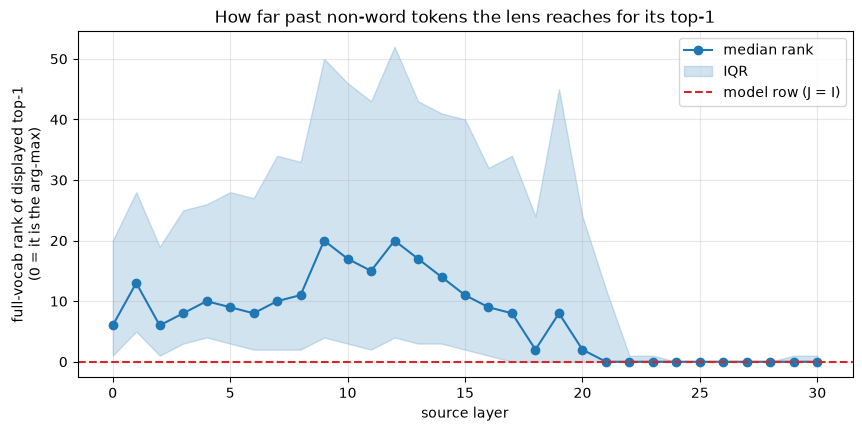

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

lens_rows = cells[~cells["is_model_row"]]
model_row = summary[summary["is_model_row"]].iloc[0]
lens_summary = summary[~summary["is_model_row"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(lens_summary["layer"], lens_summary["median_rank"], marker="o",
        color="#1f77b4", label="median rank")
ax.fill_between(lens_summary["layer"], lens_summary["p25_rank"],
                lens_summary["p75_rank"], alpha=0.2, color="#1f77b4", label="IQR")
ax.axhline(model_row["median_rank"], ls="--", color="#d62728", label="model row (J = I)")
ax.set_xlabel("source layer")
ax.set_ylabel("full-vocab rank of displayed top-1\n(0 = it is the arg-max)")
ax.set_title("How far past non-word tokens the lens reaches for its top-1")
ax.grid(alpha=0.3); ax.legend(); plt.show()

**Early layers are more tied to non-word tokens**

The early layers of the model show a stronger preference for non-word tokens, with a focus on top-1 word tokens arising around layer 21. This may suggest some focus on prompt structure, where the model expects more punctuation or other non-word characters before reaching a deeper conceptual anchor that is aligned with a valid word-token output.

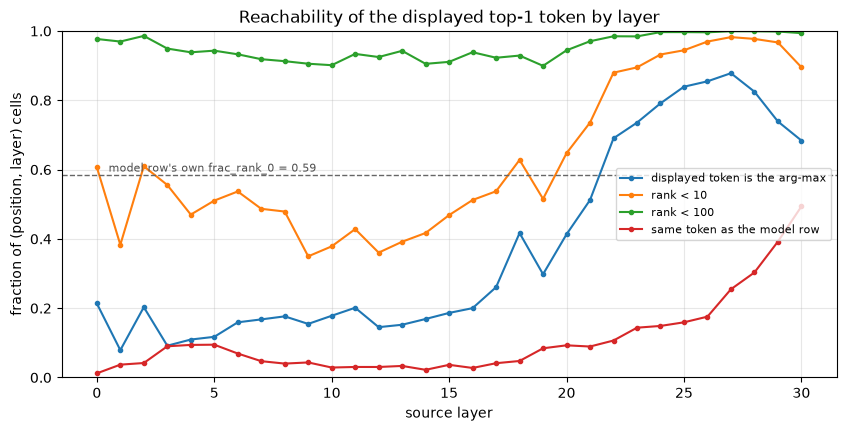

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for column, label in [("frac_rank_0", "displayed token is the arg-max"),
                      ("frac_rank_lt_10", "rank < 10"),
                      ("frac_rank_lt_100", "rank < 100"),
                      ("agreement_with_model", "same token as the model row")]:
    ax.plot(lens_summary["layer"], lens_summary[column], marker="o", ms=3, label=label)
ax.axhline(model_row["frac_rank_0"], ls="--", color="0.4", lw=1)
ax.annotate(f"model row's own frac_rank_0 = {model_row['frac_rank_0']:.2f}",
            (0.5, model_row["frac_rank_0"]), fontsize=8, va="bottom", color="0.3")
ax.set_xlabel("source layer"); ax.set_ylabel("fraction of (position, layer) cells")
ax.set_ylim(0, 1); ax.set_title("Reachability of the displayed top-1 token by layer")
ax.grid(alpha=0.3); ax.legend(fontsize=8); plt.show()

**Overlap with the model's own output rises only in the last few layers**

The lens's displayed token rarely matches the model's actual output token: agreement stays under 0.15 until layer 24, then climbs steeply to 0.49 by layer 30. Separately, the displayed word token is usually shallow *within its own distribution* — inside the top-100 at almost every layer, and inside the top-10 for ~90% of cells past layer 23.

These are different measurements, and the distinction matters: `frac_rank_lt_10/100` describes how far the display mask had to reach past punctuation to find a word, **not** where the model's output token sits in the lens distribution. (That second quantity is not recorded here — it needs per-target rank tracking.) The pattern is still consistent with earlier layers holding related-but-distinct concepts, with focus returning to the output only near the end.

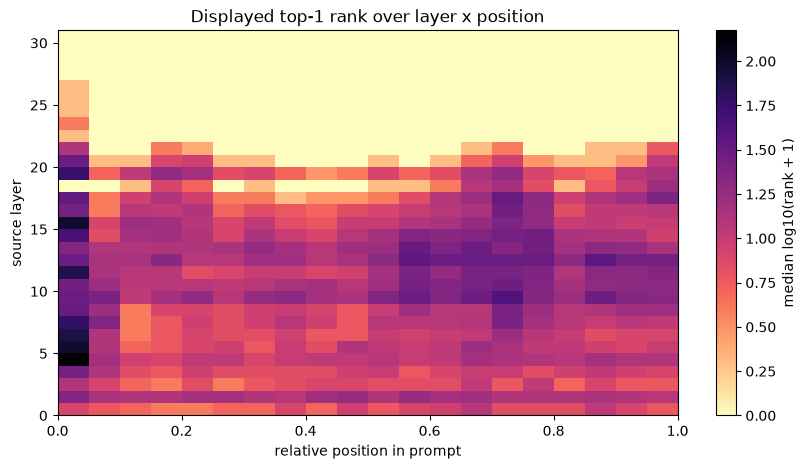

In [16]:
n_bins = 20
binned = lens_rows.assign(
    pos_bin=np.clip((lens_rows["rel_position"] * n_bins).astype(int), 0, n_bins - 1),
    log10_rank=np.log10(lens_rows["top1_rank"] + 1.0))
pivot = binned.pivot_table(index="layer", columns="pos_bin",
                           values="log10_rank", aggfunc="median").sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(np.linspace(0, 1, pivot.shape[1] + 1),
                     np.append(pivot.index, pivot.index[-1] + 1),
                     pivot.to_numpy(), cmap="magma_r", shading="flat")
fig.colorbar(mesh, ax=ax, label="median log10(rank + 1)")
ax.set_xlabel("relative position in prompt"); ax.set_ylabel("source layer")
ax.set_title("Displayed top-1 rank over layer x position"); plt.show()

**The prompt's first position is the weakest and the last to resolve**

Through the early and middle layers the opening position's top-1 word sits far deeper than the rest of the prompt — median rank ~95 at layer 5, versus ~7 across later positions — and it stays unresolved until ~layer 23, well after every other position has locked to rank 0.

Plausibly a structural artifact rather than a semantic one: with no left context, the first position has almost nothing to condition on. (Note the colour scale is reversed — dark means *high* rank, i.e. weaker.)

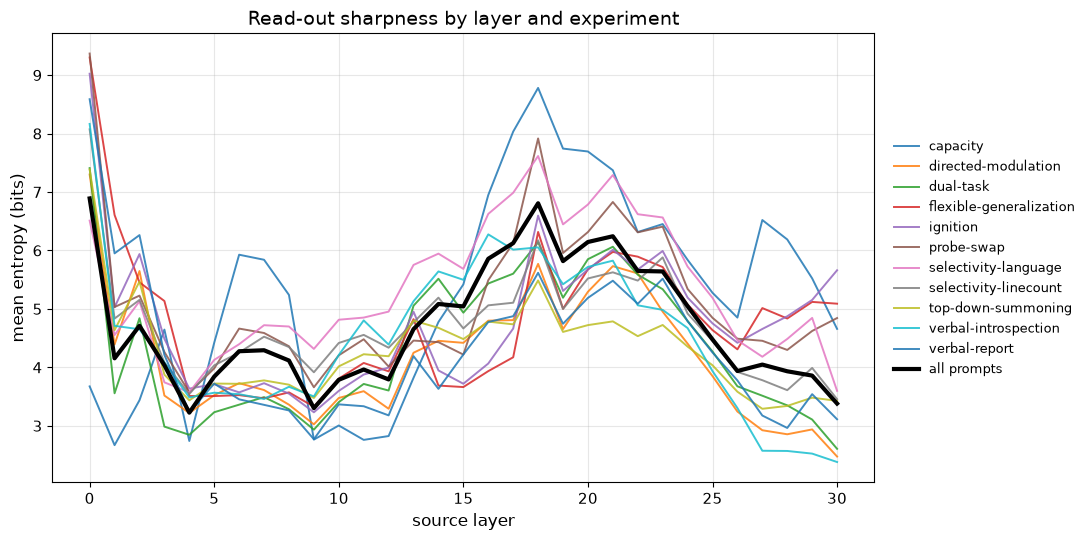

In [17]:
# Read-out sharpness, per experiment. Full width for presentation legibility;
# the legend sits outside the axes so it never covers the L18-L21 spike.
fig, ax = plt.subplots(figsize=(11, 5.5))
for experiment, group in lens_rows.groupby("experiment"):
    ax.plot(*zip(*group.groupby("layer")["entropy_bits"].mean().items()),
            lw=1.4, alpha=0.85, label=experiment)
ax.plot(*zip(*lens_rows.groupby("layer")["entropy_bits"].mean().items()),
        lw=3.0, color="k", label="all prompts", zorder=5)
ax.set_xlabel("source layer", fontsize=12)
ax.set_ylabel("mean entropy (bits)", fontsize=12)
ax.set_title("Read-out sharpness by layer and experiment", fontsize=14)
ax.tick_params(labelsize=11); ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(); plt.show()

**Entropy is largely similar through all prompt categories**

Entropy follows similar trends through the model layers for most categories, though a couple stand out. `capacity` shows larger peaks that roughly align with the other categories, while `flexible-generalization` (3.66) and `ignition` (3.72) show tighter entropy troughs, particularly at layer 15. At that layer the broadest read-outs are `selectivity-language` (5.68) and `verbal-introspection` (5.50).

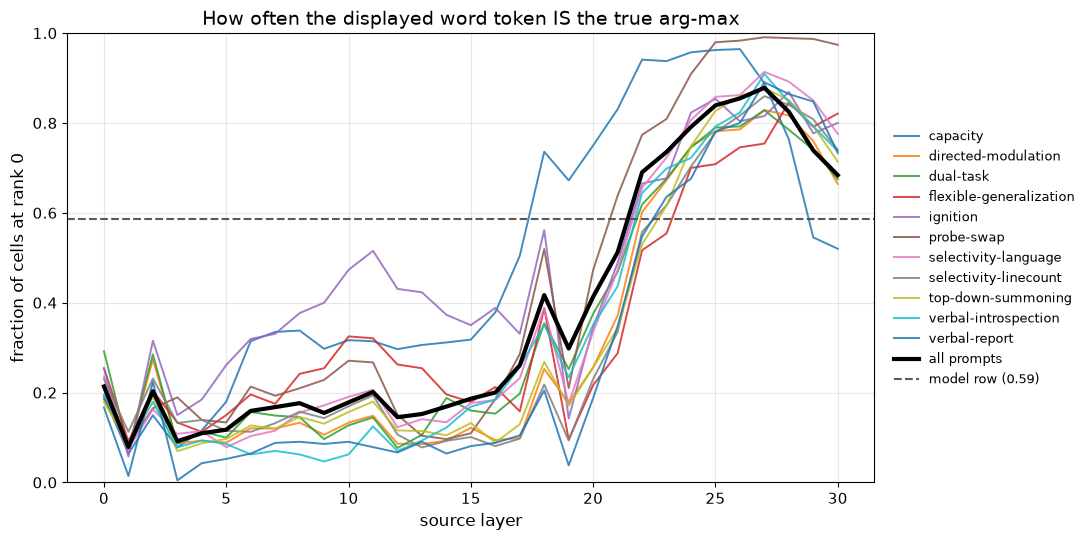

In [18]:
# How often the displayed word token is also the true unmasked arg-max, with
# the model row's own rate as the reference line (see SS7: it, not 1.0, is the
# meaningful ceiling).
fig, ax = plt.subplots(figsize=(11, 5.5))
for experiment, group in lens_rows.groupby("experiment"):
    ax.plot(*zip(*group.groupby("layer")["is_argmax"].mean().items()),
            lw=1.4, alpha=0.85, label=experiment)
ax.plot(*zip(*lens_rows.groupby("layer")["is_argmax"].mean().items()),
        lw=3.0, color="k", label="all prompts", zorder=5)
ax.axhline(model_row["frac_rank_0"], ls="--", color="0.35", lw=1.5,
           label=f"model row ({model_row['frac_rank_0']:.2f})")
ax.set_xlabel("source layer", fontsize=12)
ax.set_ylabel("fraction of cells at rank 0", fontsize=12)
ax.set_title("How often the displayed word token IS the true arg-max", fontsize=14)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=11); ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(); plt.show()

**Word-selection sharpens into the late-middle band, then relaxes**

The share of cells where the displayed word token is also the true arg-max falls to ~0.08 by layer 3, then rises steeply from layer 18 to peak at ~0.88 around layer 27, before easing back to ~0.68 at layer 30.

All eleven prompt groups share inflection points at layer 3 and again at layers 18–19, suggesting the change is related to model architecture or a more fundamental trained structure rather than to any particular task.

Note this is `frac_rank_0` — whether the displayed word is the arg-max of the *lens's own* distribution. It is not agreement with the model's output, which is a separate series (0.01 at layer 0) shown in the reachability figure above.

## 7. Observations

The three findings below are the reason the marginal read-out is worth
computing even though it is not, on its own, the interesting statistic.

**(a) Is the unmasked arg-max actually punctuation / whitespace?**

`frac_rank_0 < 1` could mean the lens is failing to surface a word, or it could
mean the correct token there simply is not a word. `raw_top1_id` — the
*unmasked* arg-max, recorded alongside the displayed one — settles it.

In [19]:
V = max(int(cells["raw_top1_id"].max()) + 1, 248320)
wordlike = _meaningful_token_mask(tokenizer, V, torch.device("cpu")).numpy()
cells["raw_is_wordlike"] = wordlike[cells["raw_top1_id"].to_numpy()]

rows = []
for (layer, is_model), group in cells.groupby(["layer", "is_model_row"], sort=True):
    counts = group["raw_top1_id"].value_counts()
    rows.append({
        "layer_label": f"L{int(layer)}" + (" (model)" if is_model else ""),
        "is_model_row": is_model,
        "raw_argmax_wordlike": group["raw_is_wordlike"].mean(),
        "displayed_is_argmax": group["is_argmax"].mean(),
        **{f"raw_top{i+1}": f"{decode(t)!r} {n/counts.sum():.0%}"
           for i, (t, n) in enumerate(counts.head(3).items())},
    })
raw_argmax_table = pd.DataFrame(rows)
raw_argmax_table[raw_argmax_table["layer_label"].str.strip("L").str.split().str[0]
                 .astype(int).isin([0, 5, 10, 15, 18, 20, 25, 27, 30, 31])]

,layer_label,is_model_row,raw_argmax_wordlike,displayed_is_argmax,raw_top1,raw_top2,raw_top3
0,L0,False,0.210057,0.213615,"',' 13%",' --' 11%,' ``' 9%
5,L5,False,0.115966,0.117366,'.' 7%,' ' 5%,'...' 4%
10,L10,False,0.176807,0.178149,' ...' 10%,'____' 8%,'<|im_end|>' 7%
15,L15,False,0.184565,0.186373,'____' 13%,'.' 9%,"'\\""' 7%"
18,L18,False,0.414280,0.416905,'____' 8%,'<|im_end|>' 7%,'?\\' 5%
20,L20,False,0.410488,0.413288,"'\\""' 5%",'<|im_end|>' 5%,'____' 5%
25,L25,False,0.838710,0.839176,' Smith' 2%,'<|im_end|>' 2%,' Mike' 2%
27,L27,False,0.877501,0.878201,'<|im_end|>' 2%,' word' 2%,"',' 1%"
30,L30,False,0.683311,0.683953,"',' 13%",'.' 5%,'\n' 3%
31,L31 (model),True,0.584145,0.585487,"',' 13%",'<|im_end|>' 10%,' and' 6%


The model's *own* row is the control: it surfaces a word-like arg-max only ~58%
of the time, and its three most common arg-maxes are `','`, `'<|im_end|>'` and
`' and'`. At an arbitrary mid-prompt position the correct next token genuinely
often is punctuation — so `rank > 0` is largely a property of natural text, not
a lens deficiency, and **~0.58 is the meaningful ceiling here, not 1.0**.

**(b) How dominant is the modal displayed token?**

In [20]:
rows = []
for (layer, is_model), group in cells.groupby(["layer", "is_model_row"], sort=True):
    counts = group["top1_id"].value_counts()
    rows.append({
        "layer_label": f"L{int(layer)}" + (" (model)" if is_model else ""),
        "modal_top1": repr(decode(counts.index[0])),
        "modal_share": counts.iloc[0] / counts.sum(),
        "top5_share": counts.head(5).sum() / counts.sum(),
        "distinct_tokens": len(counts),
        "top5_tokens": ", ".join(repr(decode(t)) for t in counts.head(5).index),
    })
modal_table = pd.DataFrame(rows)
modal_table.style.format({"modal_share": "{:.1%}", "top5_share": "{:.1%}"})

,layer_label,modal_top1,modal_share,top5_share,distinct_tokens,top5_tokens
0,L0,'s',9.9%,29.6%,913,"'s', ' in', ' the', 'ing', 'ся'"
1,L1,'s',9.2%,33.2%,844,"'s', ' Â', 'â', ' the', ' â'"
2,L2,'s',17.1%,43.1%,696,"'s', '²', ' at', ' the', ' in'"
3,L3,' and',10.5%,30.4%,1108,"' and', 's', ' the', ' what', 'ly'"
4,L4,' and',10.1%,31.4%,1042,"' and', 's', ' the', ' of', ' in'"
5,L5,' and',10.7%,27.7%,1269,"' and', 's', ' the', ' what', ' of'"
6,L6,'s',6.6%,21.1%,1363,"'s', ' and', ' the', ' what', ' of'"
7,L7,'s',6.9%,18.3%,1472,"'s', ' what', ' the', ' East', '1'"
8,L8,' what',5.8%,17.1%,1524,"' what', 's', ' the', '1', '在'"
9,L9,' what',5.4%,17.1%,1542,"' what', 's', ' the', ' What', ' words'"


**(c) Does aggregating over positions dilute the signal?**

A natural worry about a per-layer table aggregated over every position: the few
content-carrying positions might be swamped by filler. Comparing all positions
against the final position only tests that directly.

In [21]:
last = cells.groupby("uid")["position"].transform("max")
cells["is_final_pos"] = cells["position"] == last
lens_only = cells[~cells.is_model_row]

position_table = (
    lens_only.groupby("layer")
    .apply(lambda g: pd.Series({
        "agreement_all_positions": g["agrees_with_model"].mean(),
        "agreement_final_position": g[g.is_final_pos]["agrees_with_model"].mean(),
        "rank0_all_positions": g["is_argmax"].mean(),
        "rank0_final_position": g[g.is_final_pos]["is_argmax"].mean(),
    }), include_groups=False)
    .reset_index()
)
position_table["agreement_delta"] = (position_table["agreement_final_position"]
                                     - position_table["agreement_all_positions"])
position_table.style.format({c: "{:.3f}" for c in position_table.columns if c != "layer"})

,layer,agreement_all_positions,agreement_final_position,rank0_all_positions,rank0_final_position,agreement_delta
0,0,0.012,0.000,0.214,0.072,-0.012
1,1,0.037,0.024,0.079,0.024,-0.013
2,2,0.042,0.031,0.203,0.096,-0.011
3,3,0.090,0.045,0.092,0.068,-0.046
4,4,0.094,0.045,0.110,0.113,-0.050
5,5,0.095,0.045,0.117,0.113,-0.050
6,6,0.069,0.041,0.159,0.168,-0.028
7,7,0.047,0.041,0.168,0.161,-0.006
8,8,0.040,0.045,0.176,0.178,0.004
9,9,0.043,0.045,0.155,0.182,0.001


### What the numbers say

Throughout, **"rank-0 rate"** means `frac_rank_0`: the fraction of
`(position, layer)` cells where the displayed word-like token is *also* the
true unmasked arg-max — i.e. the lens is pointing at a word rather than
reaching past punctuation to find one.

**1. The rank-0 rate is not a quality score, and 1.0 is the wrong ceiling.**
The model's *own* output row has a word-like arg-max only ~58% of the time.
At an arbitrary mid-prompt position the correct next token genuinely often
*is* a comma, a newline, or `<|im_end|>` — the three most common raw arg-maxes
at the model row. So `rank > 0` is mostly a property of natural text, not a
lens deficiency. Measured against that ~0.58 baseline rather than against 1.0,
**the lens around L24–L27 points at a word more reliably than the model's own
output does.**

**2. The rank-0 rate is not monotonic toward the output head.**
It dips to ~0.09 in the early layers, climbs steeply from L18, peaks around
**L27 (~0.88)**, then *falls back* to ~0.68 at L30 and ~0.58 at the model row.
The mid-late band is where the read-out is most word-like — consistent with the
paper's framing of a mid-network workspace, and exactly the band the bias
experiments will target. Note also that the entropy curve **spikes around
L18–L21** at the same time as the rank collapse: the distribution broadens
precisely where it starts locking onto words.

**3. The marginal top-1 is a weak statistic, by construction.**
The modal displayed token at any mid/late layer is only a **2–4% plurality**
among 500–600 distinct tokens, so "the typical top-1 token" is not a meaningful
object. Position-averaging is not the main culprit — final-position-only
agreement tracks the all-position number closely. The real limitation is that
this is an **unconditional** read-out: it asks "what is on top here", and mixes
a handful of content-carrying positions into a large majority of filler.


### Reproducibility

- Deterministic given `SEED`; selection is prefix-stable, so raising
  `PER_EXPERIMENT` against an existing `_sweep_cache/` computes only the
  increment.
- Runtime scales as roughly `2.9s + 0.079s x n_positions` per prompt on an M4
  Air; the 292-prompt run above takes ~40 min, peaking at ~3.7 GB RSS.
- The full package version of this code, with a CLI and tests, is at
  [csinatra/jacobian-lens @ experiments-sweep](https://github.com/csinatra/jacobian-lens/tree/experiments-sweep).